<a href="https://colab.research.google.com/github/evucelic/Diplomski-Projekt/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install hmmlearn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from hmmlearn import hmm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Main questions
1. What exactly changes across regimes
2. Are Deep Models actually necessary and better than benchmarks
3. How to handle temporal dependencies
4. How many regimes actually exist in the data

TODO ADD factors to the dataset

In [ ]:
data = pd.read_csv(
    "/content/drive/MyDrive/data_dipl_proj/merged_100_portfolios_ff5_daily.csv",
    parse_dates=True,
    low_memory=False,
).set_index("Date")

SENTINEL_VALUES = [-99.99, -999, -999.0, -100, -100.0]
data = (
    data.replace(r'^\s*$', np.nan, regex=True)
        .replace({v: np.nan for v in SENTINEL_VALUES})
        .apply(pd.to_numeric, errors="coerce")
        / 100
)
data.index = pd.to_datetime(data.index)

FACTOR_COLS = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF"]
PORTFOLIO_COLS = [c for c in data.columns if c not in FACTOR_COLS]

,SMALL LoBM,ME1 BM2,ME1 BM3,ME1 BM4,ME1 BM5,ME1 BM6,ME1 BM7,ME1 BM8,ME1 BM9,SMALL HiBM,...,ME10 BM7,ME10 BM8,ME10 BM9,BIG HiBM,Mkt-RF,SMB,HML,RMW,CMA,RF
Date,,,,,,,,,,,,,,,,,,,,,
1963-07-01,-0.20,0.28,-0.44,-1.65,-0.15,-0.93,0.09,-0.93,-0.75,-0.84,...,-0.22,-1.01,-1.35,-0.35,-0.67,0.00,-0.34,-0.01,0.16,0.01
1963-07-02,-0.23,0.93,-0.27,0.69,0.40,0.29,0.44,0.46,0.20,0.68,...,0.47,1.02,1.77,0.00,0.79,-0.26,0.26,-0.07,-0.20,0.01
1963-07-03,0.54,0.79,0.87,0.59,1.15,0.38,0.43,0.30,-0.24,0.65,...,1.05,0.20,0.06,0.35,0.63,-0.17,-0.09,0.18,-0.34,0.01
1963-07-05,1.75,-0.89,0.02,-0.30,0.63,0.57,0.05,-0.11,0.93,0.24,...,-0.02,-0.04,0.42,0.00,0.40,0.08,-0.27,0.09,-0.34,0.01
1963-07-08,1.06,-1.26,-1.33,0.25,0.28,-1.22,-0.96,-0.14,-0.86,-0.96,...,-0.17,-1.52,-0.91,-1.38,-0.63,0.04,-0.18,-0.29,0.14,0.01


In [ ]:
def chronological_split(df, train_frac=0.70, val_frac=0.15):
    n = len(df)
    i1, i2 = int(n * train_frac), int(n * (train_frac + val_frac))
    return df.iloc[:i1].copy(), df.iloc[i1:i2].copy(), df.iloc[i2:].copy()


train_raw, val_raw, test_raw = chronological_split(data)

mask_train = train_raw.notna().astype(np.float32)
mask_val   = val_raw.notna().astype(np.float32)
mask_test  = test_raw.notna().astype(np.float32)

scaler = StandardScaler()
train_scaled = pd.DataFrame(scaler.fit_transform(train_raw.fillna(0)),
                             index=train_raw.index, columns=train_raw.columns)
val_scaled   = pd.DataFrame(scaler.transform(val_raw.fillna(0)),
                             index=val_raw.index,   columns=val_raw.columns)
test_scaled  = pd.DataFrame(scaler.transform(test_raw.fillna(0)),
                             index=test_raw.index,  columns=test_raw.columns)

train_masked = train_scaled.where(mask_train.astype(bool))
val_masked   = val_scaled.where(mask_val.astype(bool))
test_masked  = test_scaled.where(mask_test.astype(bool))

print("Train:", train_raw.index.min().date(), "->", train_raw.index.max().date(), train_raw.shape)
print("Val:  ", val_raw.index.min().date(),   "->", val_raw.index.max().date(),   val_raw.shape)
print("Test: ", test_raw.index.min().date(),  "->", test_raw.index.max().date(),  test_raw.shape)

In [ ]:
def _log_emission(port_ret, factor_ret, obs_mask, intercepts, loadings, resid_std):
    T, K = port_ret.shape[0], intercepts.shape[0]
    resid_var = np.maximum(resid_std ** 2, 1e-8)
    log_emit = np.zeros((T, K))
    for k in range(K):
        pred   = intercepts[k] + factor_ret @ loadings[k].T
        sq_err = (port_ret - pred) ** 2
        ll     = -0.5 * (np.log(2 * np.pi * resid_var) + sq_err / resid_var)
        ll[~obs_mask] = 0.0
        log_emit[:, k] = ll.sum(axis=1)
    return log_emit


def _forward_backward(log_emit, pi0, A):
    T, K   = log_emit.shape
    log_pi = np.log(np.clip(pi0, 1e-12, 1))
    log_A  = np.log(np.clip(A,   1e-12, 1))

    alpha = np.zeros((T, K))
    alpha[0] = log_pi + log_emit[0]
    for t in range(1, T):
        alpha[t] = log_emit[t] + logsumexp(alpha[t-1, :, None] + log_A, axis=0)
    log_lik = logsumexp(alpha[-1])

    beta = np.zeros((T, K))
    for t in range(T - 2, -1, -1):
        beta[t] = logsumexp(log_A + log_emit[t+1] + beta[t+1], axis=1)

    log_gamma = alpha + beta
    log_gamma -= logsumexp(log_gamma, axis=1, keepdims=True)
    gamma = np.exp(log_gamma)

    xi = np.zeros((T - 1, K, K))
    for t in range(T - 1):
        lp  = alpha[t, :, None] + log_A + log_emit[t+1] + beta[t+1]
        lp -= logsumexp(lp)
        xi[t] = np.exp(lp)

    return gamma, xi, log_lik


def _m_step_regression(port_ret, design, obs_mask, gamma, K, ridge=1e-5):
    P, F = port_ret.shape[1], design.shape[1] - 1
    intercepts = np.zeros((K, P))
    loadings   = np.zeros((K, P, F))
    for k in range(K):
        w = np.sqrt(np.clip(gamma[:, k], 1e-12, None))
        for p in range(P):
            obs = obs_mask[:, p]
            if obs.sum() < F + 2:
                continue
            Xw   = design[obs] * w[obs, None]
            yw   = port_ret[obs, p] * w[obs]
            coef = np.linalg.solve(Xw.T @ Xw + ridge * np.eye(F + 1), Xw.T @ yw)
            intercepts[k, p] = coef[0]
            loadings[k, p]   = coef[1:]
    return intercepts, loadings


def _m_step_resid_std(port_ret, factor_ret, obs_mask, gamma, intercepts, loadings):
    K, P = intercepts.shape
    sse  = np.zeros(P)
    for k in range(K):
        pred   = intercepts[k] + factor_ret @ loadings[k].T
        sq_err = (port_ret - pred) ** 2
        sq_err[~obs_mask] = 0.0
        sse += (gamma[:, k, None] * sq_err).sum(axis=0)
    return np.sqrt(np.maximum(sse / np.maximum(obs_mask.sum(0), 1), 1e-8))


def _m_step_markov(gamma, xi, sticky=50.0):
    pi0 = np.clip(gamma[0], 1e-12, None)
    pi0 /= pi0.sum()
    K = gamma.shape[1]
    A = xi.sum(0) + sticky * np.eye(K)
    A /= A.sum(1, keepdims=True)
    return pi0, A

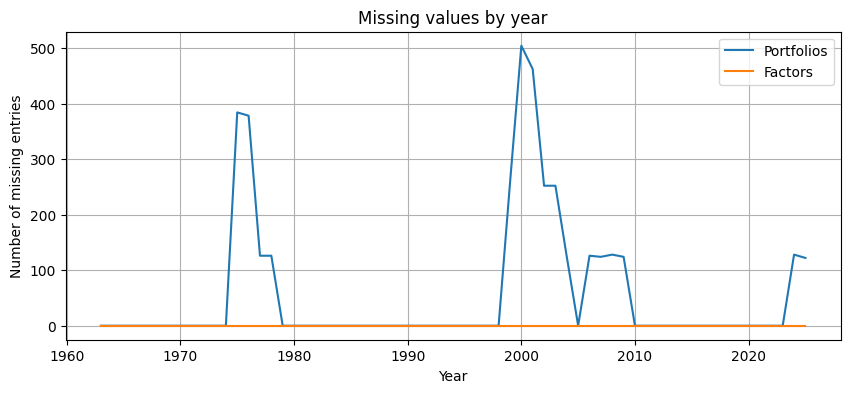

In [ ]:
def fit_hmm_factor(port_ret, factor_ret, obs_mask, K=3,
                   max_iter=50, tol=1e-4, ridge=1e-5, sticky=50.0, seed=0):
    T     = port_ret.shape[0]
    design = np.column_stack([np.ones(T), factor_ret])
    rng   = np.random.default_rng(seed)
    gamma = rng.dirichlet(np.ones(K), size=T)
    pi0   = np.full(K, 1.0 / K)
    A     = np.where(np.eye(K), 0.95, 0.05 / (K - 1))

    intercepts, loadings = _m_step_regression(port_ret, design, obs_mask, gamma, K, ridge)
    resid_std = _m_step_resid_std(port_ret, factor_ret, obs_mask, gamma, intercepts, loadings)

    prev_ll = -np.inf
    for _ in range(max_iter):
        log_emit = _log_emission(port_ret, factor_ret, obs_mask, intercepts, loadings, resid_std)
        gamma, xi, ll = _forward_backward(log_emit, pi0, A)
        pi0, A        = _m_step_markov(gamma, xi, sticky)
        intercepts, loadings = _m_step_regression(port_ret, design, obs_mask, gamma, K, ridge)
        resid_std = _m_step_resid_std(port_ret, factor_ret, obs_mask, gamma, intercepts, loadings)
        if abs(ll - prev_ll) < tol:
            break
        prev_ll = ll

    return dict(ll=ll, pi0=pi0, A=A, gamma=gamma,
                states=gamma.argmax(1), intercepts=intercepts,
                loadings=loadings, resid_std=resid_std)


def bic(ll, K, P, F, T):
    n_params = (K - 1) + K * (K - 1) + K * P * (1 + F) + P
    return -2 * ll + n_params * np.log(T)

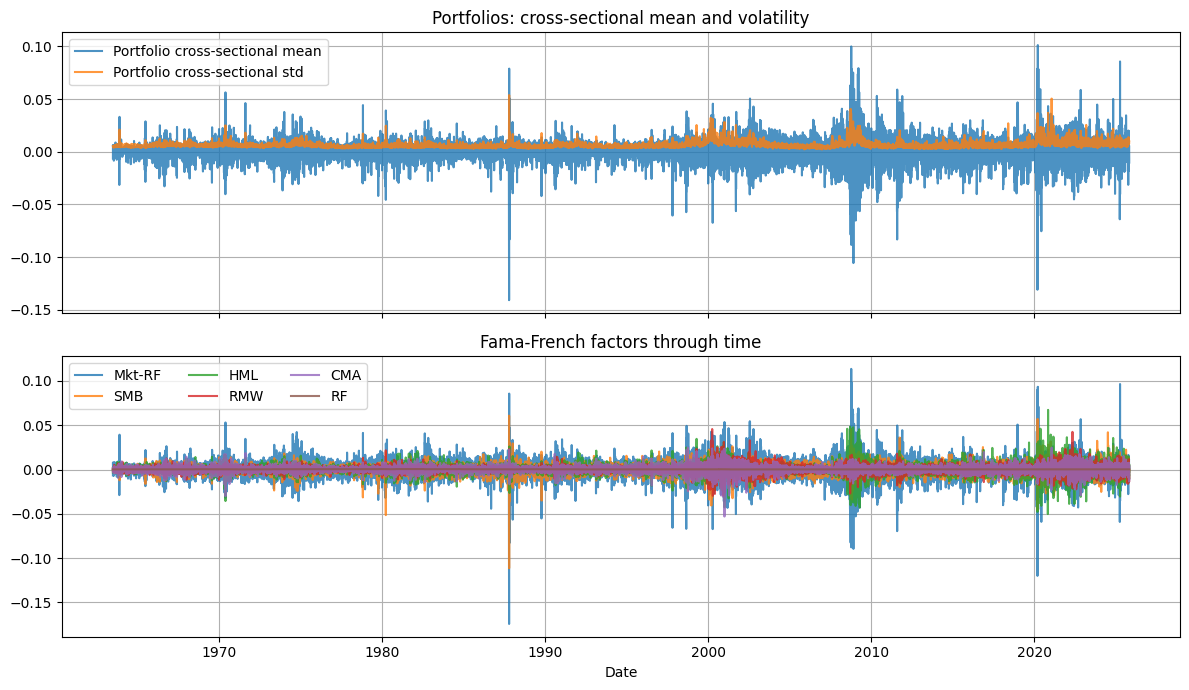

In [ ]:
port_np   = train_masked[PORTFOLIO_COLS].fillna(0).to_numpy(dtype=np.float64)
factor_np = train_masked[FACTOR_COLS].to_numpy(dtype=np.float64)
mask_np   = mask_train[PORTFOLIO_COLS].to_numpy(dtype=bool)

valid     = np.all(np.isfinite(factor_np), axis=1)
port_np, factor_np, mask_np = port_np[valid], factor_np[valid], mask_np[valid]
plot_idx  = train_masked.index[valid]

results_A, models_A = [], {}
for K in [2, 3]:
    best = max(
        (fit_hmm_factor(port_np, factor_np, mask_np, K=K, seed=s) for s in range(5)),
        key=lambda m: m["ll"]
    )
    b = bic(best["ll"], K, len(PORTFOLIO_COLS), len(FACTOR_COLS), port_np.shape[0])
    results_A.append({"K": K, "log_likelihood": best["ll"], "BIC": b})
    models_A[K] = best

results_A_df = pd.DataFrame(results_A).sort_values("BIC").reset_index(drop=True)
best_K_A     = int(results_A_df.iloc[0]["K"])
model_A      = models_A[best_K_A]
print(results_A_df)
print(f"Selected K={best_K_A}")

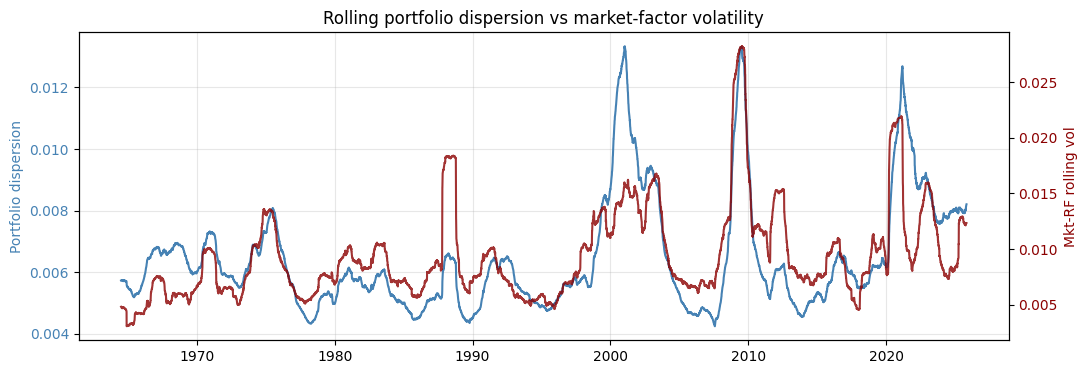

In [ ]:
N_PCA = 5
pca = PCA(n_components=N_PCA, random_state=0)
train_pca = pca.fit_transform(train_scaled[PORTFOLIO_COLS].fillna(0))
test_pca  = pca.transform(test_scaled[PORTFOLIO_COLS].fillna(0))
print(f"PCA top-{N_PCA} explained variance: {pca.explained_variance_ratio_.sum():.2%}")

results_B, models_B = [], {}
for K in [2, 3]:
    m = hmm.GaussianHMM(n_components=K, covariance_type="full",
                        n_iter=200, tol=1e-4, random_state=0)
    m.fit(train_pca)
    train_ll = m.score(train_pca)
    test_ll  = m.score(test_pca)
    k_params = K**2 + K * N_PCA + K * N_PCA * (N_PCA + 1) // 2
    b = -2 * train_ll + k_params * np.log(len(train_pca))
    results_B.append({"K": K, "train_ll": train_ll, "test_ll": test_ll, "BIC": b})
    models_B[K] = m

results_B_df = pd.DataFrame(results_B).sort_values("BIC").reset_index(drop=True)
best_K_B     = int(results_B_df.iloc[0]["K"])
model_B      = models_B[best_K_B]
train_states_B = model_B.predict(train_pca)
print(results_B_df)
print(f"Selected K={best_K_B}")

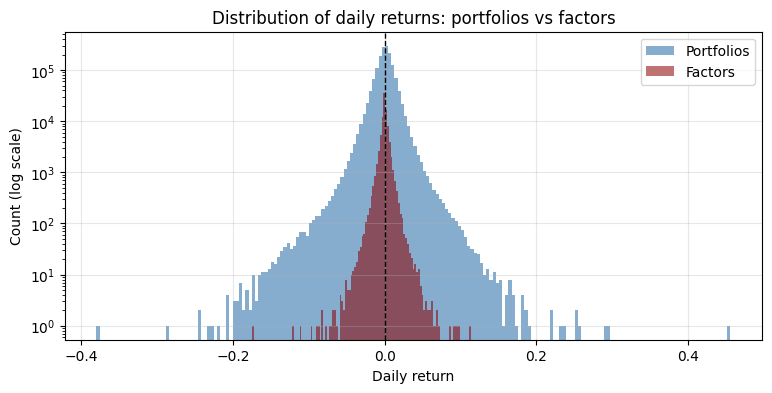

In [ ]:
gamma_A  = model_A["gamma"]
states_A = model_A["states"]

fig, axes = plt.subplots(3, 1, figsize=(14, 12), constrained_layout=True)

for k in range(best_K_A):
    axes[0].plot(plot_idx, gamma_A[:, k], label=f"State {k}", alpha=0.85)
axes[0].set_title(f"HMM+Factor posteriors (K={best_K_A})")
axes[0].set_ylabel("P(state | data)")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(plot_idx, states_A, color="black", lw=0.8)
axes[1].set_yticks(range(best_K_A))
axes[1].set_title("Most likely state"); axes[1].grid(alpha=0.3)

mean_abs = np.abs(model_A["loadings"]).mean(axis=1)
x, w = np.arange(len(FACTOR_COLS)), 0.8 / best_K_A
for k in range(best_K_A):
    axes[2].bar(x + k * w, mean_abs[k], width=w, label=f"State {k}")
axes[2].set_xticks(x + w * (best_K_A - 1) / 2)
axes[2].set_xticklabels(FACTOR_COLS)
axes[2].set_title("Mean |factor loading| by state")
axes[2].legend(); axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Benchmark A: HMM + Factor Regression", fontsize=13)
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


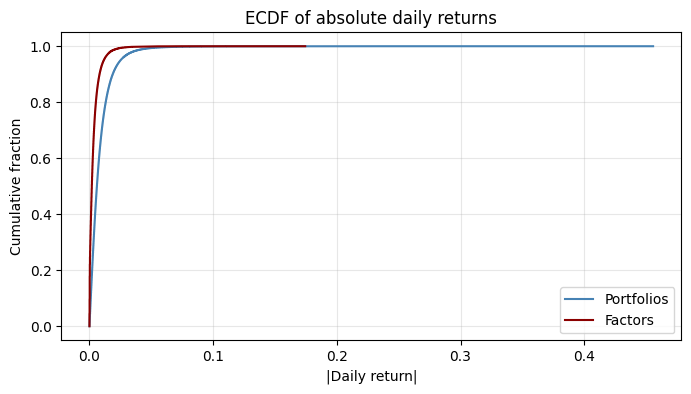

In [ ]:
cum_pc1 = np.cumsum(train_pca[:, 0])
colors  = ["green", "red", "orange", "purple"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True)

axes[0].plot(cum_pc1, color="black", lw=1.2, label="Cumulative PC1")
for k in range(best_K_B):
    axes[0].fill_between(range(len(train_states_B)),
                         cum_pc1.min(), cum_pc1.max(),
                         where=(train_states_B == k),
                         color=colors[k], alpha=0.25, label=f"Regime {k}")
axes[0].set_title(f"PCA+HMM regimes (K={best_K_B})")
axes[0].legend(loc="upper left"); axes[0].grid(alpha=0.3)

axes[1].imshow(model_B.transmat_, cmap="Blues", aspect="auto", vmin=0, vmax=1)
axes[1].set_title("Transition matrix")
axes[1].set_xticks(range(best_K_B)); axes[1].set_yticks(range(best_K_B))
for i in range(best_K_B):
    for j in range(best_K_B):
        axes[1].text(j, i, f"{model_B.transmat_[i,j]:.2f}",
                     ha="center", va="center", color="black")

plt.suptitle("Benchmark B: PCA + HMM", fontsize=13)
plt.show()

In [ ]:
def evaluate_hmm_factor(model, port_ret, factor_ret, obs_mask):
    log_emit = _log_emission(port_ret, factor_ret, obs_mask,
                             model["intercepts"], model["loadings"], model["resid_std"])
    _, _, ll = _forward_backward(log_emit, model["pi0"], model["A"])
    return ll


def score_splits(model_a, model_b, pca):
    rows = []
    for split, port_df, factor_df, mask_df in [
        ("val",  val_masked,  val_masked,  mask_val),
        ("test", test_masked, test_masked, mask_test),
    ]:
        p  = port_df[PORTFOLIO_COLS].fillna(0).to_numpy(dtype=np.float64)
        f  = factor_df[FACTOR_COLS].to_numpy(dtype=np.float64)
        m  = mask_df[PORTFOLIO_COLS].to_numpy(dtype=bool)
        ok = np.all(np.isfinite(f), axis=1)
        p, f, m = p[ok], f[ok], m[ok]

        ll_a = evaluate_hmm_factor(model_a, p, f, m)

        pc   = pca.transform(port_df[PORTFOLIO_COLS].fillna(0).to_numpy(dtype=np.float64))
        ll_b = model_b.score(pc)

        rows.append({"split": split, "HMM_Factor_ll": ll_a, "PCA_HMM_ll": ll_b})

    return pd.DataFrame(rows)


scores_df = score_splits(model_A, model_B, pca)
print(scores_df.to_string(index=False))

In [ ]:
mkt_train = train_masked["Mkt-RF"].to_numpy(dtype=np.float64)[valid]

regime_stats = {}
for k in range(best_K_A):
    idx = model_A["states"] == k
    regime_stats[k] = {
        "mean_mkt":  mkt_train[idx].mean(),
        "std_mkt":   mkt_train[idx].std(),
        "n_days":    idx.sum(),
        "pct":       idx.mean(),
    }

stats_df = pd.DataFrame(regime_stats).T.sort_values("mean_mkt", ascending=False)
stats_df.index.name = "state"

label_map = {}
labels    = ["bull", "bear", "sideways"]
for rank, state in enumerate(stats_df.index):
    label_map[int(state)] = labels[rank] if rank < len(labels) else f"state_{rank}"

stats_df["label"] = [label_map[int(i)] for i in stats_df.index]
print(stats_df.round(4))

# Attach labels to state sequence
state_labels_A = np.array([label_map[s] for s in model_A["states"]])

In [ ]:
fig, ax = plt.subplots(figsize=(14, 3), constrained_layout=True)

color_map = {"bull": "green", "bear": "red", "sideways": "orange"}
for label, color in color_map.items():
    mask = state_labels_A == label
    ax.fill_between(plot_idx, 0, 1, where=mask,
                    color=color, alpha=0.4, label=label, transform=ax.get_xaxis_transform())

ax.plot(plot_idx, (mkt_train - mkt_train.min()) / (mkt_train.max() - mkt_train.min()),
        color="black", lw=0.6, alpha=0.5, label="Mkt-RF (normalised)")

ax.set_title(f"HMM+Factor regime labels (K={best_K_A})")
ax.set_ylabel("Regime"); ax.set_ylim(0, 1)
ax.legend(loc="upper left"); ax.grid(alpha=0.2)
plt.show()

In [ ]:
comparison_df = pd.DataFrame([
    {
        "model":    "HMM+Factor",
        "K":        best_K_A,
        "train_ll": model_A["ll"],
        "val_ll":   scores_df.loc[scores_df.split == "val",  "HMM_Factor_ll"].item(),
        "test_ll":  scores_df.loc[scores_df.split == "test", "HMM_Factor_ll"].item(),
        "BIC":      results_A_df.iloc[0]["BIC"],
    },
    {
        "model":    "PCA+HMM",
        "K":        best_K_B,
        "train_ll": results_B_df.iloc[0]["train_ll"],
        "val_ll":   scores_df.loc[scores_df.split == "val",  "PCA_HMM_ll"].item(),
        "test_ll":  scores_df.loc[scores_df.split == "test", "PCA_HMM_ll"].item(),
        "BIC":      results_B_df.iloc[0]["BIC"],
    },
])

print(comparison_df.to_string(index=False))

splitting, scaling data

Podaci od 02.07.1945 - 31.10.2025. Podaci koji nedostaju su zamijenjeni s 0 (stacionarni trenutci)

Portfelji su formirani na temelju 2 karakteristike, size(market equity) i value (Book-to-market)

Napomena za size:
"A fundamental problem in handling accounting data is the look-ahead bias; we must not include data in forming a portfolio that was not available knowledge at the time. Of course, researchers have more information when looking into the past than agents actually had at that moment. However, abnormal excess returns from a trading strategy should not rely on an information advantage because the differential cannot be the result of informed agents’ trades. Hence, we have to lag accounting information.

We continue to lag market capitalization and firm size by one month" source: https://www.tidy-finance.org/r/value-and-bivariate-sorts.html



Kako su točno formirani portfelji?
U danom trenutku t, uzimamo cijeli universe dionica u tom trenutku i pridružimo im dvije karakteristike npr. size i value.
Recimo da svakoj dionici pridružimo size od 1-10 i value od 1-10. Vrijednosti 1-10 predstavljaju decile veličine/value s NYSE burze, računaju se jednom godišnje te su stacionarni godinu dana.

Grupiramo dionice na temelju labela i formiramo 10x10 = 100 portfelja u svakom trenutku, weightanih proporcionalno market capu (lagganom 1mj).

Ignore deep models for now

implement a HMM model with a factor regression component

PCA + HMM combo

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal, StudentT

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def forward_backward_log(emission_log_probs, init_logits, trans_logits):
    B, T, K = emission_log_probs.shape

    log_pi = F.log_softmax(init_logits, dim=0)          # (K,)
    log_A = F.log_softmax(trans_logits, dim=1)          # (K, K)

    # forward pass
    alpha = []
    a0 = log_pi.unsqueeze(0) + emission_log_probs[:, 0, :]   # (B, K)
    alpha.append(a0)

    for t in range(1, T):
        prev = alpha[-1].unsqueeze(2)                   # (B, K, 1)
        scores = prev + log_A.unsqueeze(0)              # (B, K, K)
        at = torch.logsumexp(scores, dim=1) + emission_log_probs[:, t, :]
        alpha.append(at)

    alpha = torch.stack(alpha, dim=1)                   # (B, T, K)

    # backward pass
    beta = [torch.zeros(B, K, device=emission_log_probs.device)]
    for t in range(T - 2, -1, -1):
        scores = (
            log_A.unsqueeze(0)
            + emission_log_probs[:, t + 1, :].unsqueeze(1)
            + beta[0].unsqueeze(1)
        )                                               # (B, K, K)
        bt = torch.logsumexp(scores, dim=2)             # (B, K)
        beta.insert(0, bt)

    beta = torch.stack(beta, dim=1)                     # (B, T, K)

    log_Z = torch.logsumexp(alpha[:, -1, :], dim=1)     # (B,)

    log_gamma = alpha + beta - log_Z.view(B, 1, 1)
    gamma = torch.exp(log_gamma)                        # (B, T, K)

    xi_list = []
    if T > 1:
        for t in range(T - 1):
            scores = (
                alpha[:, t, :].unsqueeze(2)
                + log_A.unsqueeze(0)
                + emission_log_probs[:, t + 1, :].unsqueeze(1)
                + beta[:, t + 1, :].unsqueeze(1)
                - log_Z.view(B, 1, 1)
            )                                           # (B, K, K)
            xi_list.append(torch.exp(scores))
        xi = torch.stack(xi_list, dim=1)                # (B, T-1, K, K)
    else:
        xi = None

    return gamma, xi, log_Z


In [ ]:
def gaussian_kl_to_states(mu_q, logvar_q, mu_p, logvar_p):
    # mu_q, logvar_q: (B, T, L)
    # mu_p, logvar_p: (K, L)

    var_q = torch.exp(logvar_q).unsqueeze(2)                  # (B, T, 1, L)
    var_p = torch.exp(logvar_p).unsqueeze(0).unsqueeze(0)     # (1, 1, K, L)

    mu_q = mu_q.unsqueeze(2)                                  # (B, T, 1, L)
    mu_p = mu_p.unsqueeze(0).unsqueeze(0)                     # (1, 1, K, L)

    logvar_q = logvar_q.unsqueeze(2)                          # (B, T, 1, L)
    logvar_p = logvar_p.unsqueeze(0).unsqueeze(0)             # (1, 1, K, L)

    kl = 0.5 * (
        logvar_p - logvar_q +
        (var_q + (mu_q - mu_p) ** 2) / var_p - 1.0
    ).sum(dim=-1)                                             # (B, T, K)

    return kl

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.mu = nn.Linear(hidden_dim, latent_dim)
        self.logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        B, T, D = x.shape
        x = x.reshape(B * T, D)

        h = F.leaky_relu(self.fc1(x))
        h = F.leaky_relu(self.fc2(h))

        mu = self.mu(h).view(B, T, -1)
        logvar = self.logvar(h).view(B, T, -1)
        return mu, logvar


class Decoder(nn.Module):
    def __init__(self, latent_dim, state_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim + state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, z, gamma):
        # z: (B*T, latent_dim)
        # gamma: (B*T, num_states) - the soft state probabilities
        x_in = torch.cat([z, gamma], dim=-1)

        h = F.leaky_relu(self.fc1(x_in))
        h = F.leaky_relu(self.fc2(h))
        return self.fc_out(h)


class HMMVAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, num_states):
        super().__init__()
        self.num_states = num_states
        self.latent_dim = latent_dim

        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, num_states, hidden_dim, input_dim)

        # HMM params
        self.init_logits = nn.Parameter(torch.zeros(num_states))
        self.trans_logits = nn.Parameter(torch.zeros(num_states, num_states))

        # Latent priors
        self.state_mu = nn.Parameter(torch.randn(num_states, latent_dim))
        self.state_logvar = nn.Parameter(torch.zeros(num_states, latent_dim))

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, gamma=None):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)

        B, T, L = z.shape

        if gamma is None:
            emission_log_probs = -gaussian_kl_to_states(
                mu, logvar, self.state_mu, self.state_logvar
            )
            with torch.no_grad():
                gamma, _, _ = forward_backward_log(
                    emission_log_probs, self.init_logits, self.trans_logits
                )

        z_flat = z.reshape(B * T, L)
        gamma_flat = gamma.reshape(B * T, self.num_states)

        x_recon = self.decoder(z_flat, gamma_flat).view(B, T, -1)

        return x_recon, mu, logvar, z, gamma


In [ ]:
def hmm_vae_loss(x, x_recon, mu, logvar, gamma, xi, model, kl_weight=1.0):
    B, T, D = x.shape

    # reconstruction term
    recon_loss = F.mse_loss(x_recon, x, reduction='sum') / (B * T)

    # latent prior matching term
    kl_all = gaussian_kl_to_states(
        mu, logvar, model.state_mu, model.state_logvar
    )                                                   # (B, T, K)

    kl_z = (gamma * kl_all).sum(dim=(1, 2)).mean() / T

    # initial-state term
    log_pi = F.log_softmax(model.init_logits, dim=0)
    init_loss = -(gamma[:, 0, :] * log_pi.unsqueeze(0)).sum(dim=1).mean()

    # transition term
    if xi is None:
        trans_loss = torch.tensor(0.0, device=x.device)
    else:
        log_A = F.log_softmax(model.trans_logits, dim=1)
        trans_loss = -(xi * log_A.unsqueeze(0).unsqueeze(0)).sum(dim=(1, 2, 3)).mean() / (T - 1)

    total_loss = recon_loss + kl_weight * (kl_z + init_loss + trans_loss)
    return total_loss


In [ ]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

data_train, data_test = train_test_split(
    data, test_size=0.15, random_state=1000, shuffle=False
)

scaler = StandardScaler()
data_train = scaler.fit_transform(data_train)
data_test = scaler.transform(data_test)

def create_windows(data, window_size=100):
    windows = []
    for i in range(len(data) - window_size + 1):
        windows.append(data[i : i + window_size])
    return torch.tensor(np.array(windows), dtype=torch.float32)

window_size = 100
batch_size = 128

X_train_seqs = create_windows(data_train, window_size)
X_test_seqs = create_windows(data_test, window_size)

train_loader = DataLoader(TensorDataset(X_train_seqs), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_seqs), batch_size=batch_size, shuffle=False)

print("Batched Train Shape:", X_train_seqs.shape) # e.g., (17395, 100, D)



Batched Train Shape: torch.Size([17395, 100, 100])


In [ ]:
train_batch = next(iter(train_loader))[0]
test_batch = next(iter(test_loader))[0]

print("train batch shape:", train_batch.shape)
print("test batch shape:", test_batch.shape)


train batch shape: torch.Size([128, 100, 100])
test batch shape: torch.Size([128, 100, 100])


In [ ]:
def train_hmm_vae_batched(model, train_loader, epochs, device, kl_anneal_cycles=4, ratio_increase=0.5):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

    total_steps = epochs * len(train_loader)
    steps_per_cycle = max(total_steps // kl_anneal_cycles, 1)
    steps_to_increase = max(int(steps_per_cycle * ratio_increase), 1)

    global_step = 0

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for (x_batch,) in train_loader:
            x_batch = x_batch.to(device) # (B, 100, D)
            B, T, D = x_batch.shape

            step_in_cycle = global_step % steps_per_cycle
            if step_in_cycle < steps_to_increase:
                kl_weight = step_in_cycle / steps_to_increase
            else:
                kl_weight = 1.0

            optimizer.zero_grad()

            mu, logvar = model.encoder(x_batch)
            z = model.reparameterize(mu, logvar)

            emission_log_probs = -gaussian_kl_to_states(
                mu, logvar, model.state_mu, model.state_logvar
            )

            gamma, xi, log_Z = forward_backward_log(
                emission_log_probs, model.init_logits, model.trans_logits
            )

            z_flat = z.reshape(B * T, model.latent_dim)
            gamma_flat = gamma.detach().reshape(B * T, model.num_states)

            x_recon = model.decoder(z_flat, gamma_flat).view(B, T, -1)

            loss = hmm_vae_loss(
                x_batch, x_recon, mu, logvar, gamma, xi, model, kl_weight=kl_weight
            )

            trans_probs = F.softmax(model.trans_logits, dim=-1)
            entropy_loss = -0.05 * (trans_probs * torch.log(trans_probs + 1e-9)).sum()
            loss += entropy_loss

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0) # Stop spikes
            optimizer.step()

            epoch_loss += loss.item()
            global_step += 1

        avg_loss = epoch_loss / len(train_loader)
        print(f"Epoch {epoch+1:03d}/{epochs} | Avg Loss: {avg_loss:.4f} | KL: {kl_weight:.2f}")

    return model


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_dim = X_train_seq.shape[-1]
hidden_dim = 64
latent_dim = 10
num_states = 2

model = HMMVAE(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    latent_dim=latent_dim,
    num_states=num_states
)

model = train_hmm_vae(
    model=model,
    X_train_seq=X_train_seq,
    epochs=100,
    device=device,
    kl_anneal_cycles=4,
    ratio_increase=0.5
)


Epoch 001/100 | Loss: 101.4523 | KL: 0.00
Epoch 010/100 | Loss: 100.5217 | KL: 0.75
Epoch 020/100 | Loss: 263.0148 | KL: 1.00
Epoch 030/100 | Loss: 102.7861 | KL: 0.33
Epoch 040/100 | Loss: 97.3434 | KL: 1.00
Epoch 050/100 | Loss: 92.2621 | KL: 1.00
Epoch 060/100 | Loss: 83.3897 | KL: 0.75
Epoch 070/100 | Loss: 73.9893 | KL: 1.00
Epoch 080/100 | Loss: 69.2853 | KL: 0.33
Epoch 090/100 | Loss: 67.3176 | KL: 1.00
Epoch 100/100 | Loss: 67.7897 | KL: 1.00


In [ ]:
from sklearn.decomposition import PCA
from torch.distributions import MultivariateNormal


def compute_mvn_baseline(data_train, data_test, ridge=1e-4):
    train_tensor = torch.tensor(data_train, dtype=torch.float32)
    test_tensor = torch.tensor(data_test, dtype=torch.float32)

    mu = train_tensor.mean(dim=0)
    centered = train_tensor - mu

    cov = (centered.T @ centered) / (train_tensor.shape[0] - 1)
    cov = cov + ridge * torch.eye(cov.shape[0])

    mvn = MultivariateNormal(loc=mu, covariance_matrix=cov)
    row_ll = mvn.log_prob(test_tensor)
    avg_ll = row_ll.mean().item()

    return avg_ll, row_ll


def compute_pca_baseline(data_train, data_test, n_components):
    pca = PCA(n_components=n_components)
    pca.fit(data_train)

    row_ll = pca.score_samples(data_test)
    avg_ll = row_ll.mean()

    return avg_ll, row_ll, pca


In [ ]:
@torch.no_grad()
def infer_states(model, data_np, window_size, device, batch_size=128):
    model.eval()

    windows = []
    for i in range(0, len(data_np) - window_size + 1, window_size):
        windows.append(data_np[i : i + window_size])

    if not windows:
        raise ValueError("window_size is larger than the data length.")

    X_windows = torch.tensor(np.array(windows), dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_windows), batch_size=batch_size, shuffle=False)

    all_gammas = []

    for (x_batch,) in loader:
        x_batch = x_batch.to(device)               # (B, T_window, D)

        mu, logvar = model.encoder(x_batch)

        emission_log_probs = -gaussian_kl_to_states(
            mu, logvar, model.state_mu, model.state_logvar
        )

        gamma, _, _ = forward_backward_log(
            emission_log_probs, model.init_logits, model.trans_logits
        )

        all_gammas.append(gamma.cpu())

    all_gammas = torch.cat(all_gammas, dim=0)       # (N_windows, T_window, K)

    total_days = all_gammas.shape[0] * all_gammas.shape[1]
    flat_gammas = all_gammas.reshape(total_days, -1) # (Total_Days, K)

    hard_states = flat_gammas.argmax(dim=-1)         # (Total_Days,)

    return hard_states, flat_gammas


@torch.no_grad()
def estimate_obs_std(model, data_np, window_size, device, batch_size=128, min_std=1e-4):
    model.eval()

    windows = []
    for i in range(0, len(data_np) - window_size + 1, window_size):
        windows.append(data_np[i : i + window_size])

    X_windows = torch.tensor(np.array(windows), dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_windows), batch_size=batch_size, shuffle=False)

    sse = None
    n = 0

    for (x_batch,) in loader:
        x_batch = x_batch.to(device)               # (B, T, D)
        B, T, D = x_batch.shape

        mu, logvar = model.encoder(x_batch)
        z = model.reparameterize(mu, logvar)

        emission_log_probs = -gaussian_kl_to_states(
            mu, logvar, model.state_mu, model.state_logvar
        )
        gamma, _, _ = forward_backward_log(
            emission_log_probs, model.init_logits, model.trans_logits
        )

        z_flat = z.reshape(B * T, model.latent_dim)
        gamma_flat = gamma.reshape(B * T, model.num_states)
        x_recon = model.decoder(z_flat, gamma_flat).view(B, T, -1)

        resid2 = (x_batch - x_recon) ** 2
        if sse is None:
            sse = resid2.sum(dim=(0, 1))
        else:
            sse += resid2.sum(dim=(0, 1))
        n += B * T

    std = torch.sqrt(torch.clamp(sse / max(n, 1), min=min_std))
    return std


@torch.no_grad()
def compute_hmmvae_log_likelihood(model, data_np, window_size, device, M=100, obs_std=None, batch_size=64):
    model.eval()

    windows = []
    for i in range(0, len(data_np) - window_size + 1, window_size):
        windows.append(data_np[i : i + window_size])

    X_windows = torch.tensor(np.array(windows), dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_windows), batch_size=batch_size, shuffle=False)

    if obs_std is not None:
        obs_std = obs_std.to(device)

    total_ll = 0.0
    total_days = 0

    for (x_batch,) in loader:
        x_batch = x_batch.to(device)               # (B, T, D)
        B, T, D = x_batch.shape
        K = model.num_states

        mu, logvar = model.encoder(x_batch)        # (B, T, L)
        std_q = torch.exp(0.5 * logvar)
        q_z_x = Normal(mu, std_q)

        emission_log_probs = []

        for k in range(K):
            mu_k = model.state_mu[k].unsqueeze(0).unsqueeze(0).expand(B, T, -1)
            std_k = torch.exp(0.5 * model.state_logvar[k]).unsqueeze(0).unsqueeze(0).expand(B, T, -1)
            p_z_k = Normal(mu_k, std_k)

            log_weights = []

            for _ in range(M):
                z = q_z_x.rsample()                # (B, T, L)

                gamma_k = torch.zeros(B * T, K, device=device)
                gamma_k[:, k] = 1.0

                z_flat = z.reshape(B * T, -1)
                x_recon = model.decoder(z_flat, gamma_k).view(B, T, -1)

                if obs_std is None:
                    p_x_z = Normal(x_recon, torch.ones_like(x_recon))
                else:
                    p_x_z = Normal(x_recon, obs_std.unsqueeze(0).unsqueeze(0).expand_as(x_recon))

                log_p_x_z = p_x_z.log_prob(x_batch).sum(dim=-1)    # (B, T)
                log_p_z_k = p_z_k.log_prob(z).sum(dim=-1)          # (B, T)
                log_q_z_x = q_z_x.log_prob(z).sum(dim=-1)          # (B, T)

                log_w = log_p_x_z + log_p_z_k - log_q_z_x         # (B, T)
                log_weights.append(log_w)

            log_weights = torch.stack(log_weights, dim=0)          # (M, B, T)
            log_emission_k = torch.logsumexp(log_weights, dim=0) - math.log(M)  # (B, T)
            emission_log_probs.append(log_emission_k)

        emission_log_probs = torch.stack(emission_log_probs, dim=-1)   # (B, T, K)

        batch_ll = 0.0
        for b in range(B):
            seq_ll = hmm_forward_logprob(
                emission_log_probs[b],  # (T, K)
                model.init_logits,
                model.trans_logits
            )
            batch_ll += seq_ll.item()

        total_ll += batch_ll
        total_days += B * T

    avg_ll = total_ll / total_days
    return total_ll, avg_ll


train_states, train_gamma = infer_states(model, data_train, window_size=100, device=device)
test_states, test_gamma = infer_states(model, data_test, window_size=100, device=device)

print("Train states shape:", train_states.shape)
print("Train state counts:", torch.bincount(train_states))
print("Test state counts:", torch.bincount(test_states))

obs_std = estimate_obs_std(model, data_train, window_size=100, device=device)

train_total_ll, train_avg_ll = compute_hmmvae_log_likelihood(
    model, data_train, window_size=100, device=device, M=100, obs_std=obs_std
)
test_total_ll, test_avg_ll = compute_hmmvae_log_likelihood(
    model, data_test, window_size=100, device=device, M=100, obs_std=obs_std
)

mvn_ll, _ = compute_mvn_baseline(data_train, data_test)
pca_ll, _, _ = compute_pca_baseline(data_train, data_test, n_components=latent_dim)

print(f"\nHMM-VAE Train Avg LL per day: {train_avg_ll:.4f}")
print(f"HMM-VAE Test Avg LL per day:  {test_avg_ll:.4f}")
print(f"MVN Baseline Test Avg LL:      {mvn_ll:.4f}")
print(f"PCA Baseline Test Avg LL:      {pca_ll:.4f}")


Train states shape: torch.Size([17400])
Train state counts: tensor([   19, 17381])
Test state counts: tensor([   6, 2994])

HMM-VAE Train Avg LL per day: -104.6452
HMM-VAE Test Avg LL per day:  -116.3979
MVN Baseline Test Avg LL:      -85.1118
PCA Baseline Test Avg LL:      -86.2479


In [ ]:
# https://stats.stackexchange.com/questions/60680/kl-divergence-between-two-multivariate-gaussians
# https://www.microsoft.com/en-us/research/blog/less-pain-more-gain-a-simple-method-for-vae-training-with-less-of-that-kl-vanishing-agony/
# https://huggingface.co/blog/NormalUhr/kl-divergence-estimator-rl-llm
# http://joschu.net/blog/kl-approx.html